In [1]:
import re
import numpy as np
import pandas as pd
import h5py
from scipy.optimize import curve_fit

In [86]:
folder='Final_Step1'
#folder='../Half_space_model/1yr_and_flux'

In [87]:
# Path to the .xmf file
file_path = folder+'/ats_vis_data.VisIt.xmf'

# Read the file content
with open(file_path, 'r') as file:
    content = file.read()

# Regular expression to match numbers between 'h5' and 'xmf'
pattern = r"h5\.(\d+)\.xmf"
matches = re.findall(pattern, content)

# Convert matches to integers
numbers = [int(match) for match in matches]

In [88]:
loc=pd.read_csv('data/mesh_final_step1.csv').iloc[:,[0,2]]
for i in range(len(numbers)):
    fin=loc.copy()
    temp=loc.copy()
    df=h5py.File(folder+'/ats_vis_data.h5', 'r')
    fin['porosity']=df['base_porosity'][str(numbers[i])]
    fin['U']=df['darcy_velocity.x'][str(numbers[i])]
    fin['W']=df['darcy_velocity.z'][str(numbers[i])]
    #fin['k']=df['permeability'][str(numbers[i])]
    fin['sat']=df['saturation_liquid'][str(numbers[i])]
    fin['time']=i
    temp['h']=df['pressure'][str(numbers[i])]
    if i==0:
        out=fin.copy()
        pressure=temp.copy()
        continue
    out=pd.concat([out,fin])
    pressure=pd.concat([pressure,temp])
    #break

In [89]:
#Assign homogeneous resistivity from field data
df=out.copy()
df['cond']=0
df['cond'][df["porosity"]>=0.4]=1/40# 40 original used
df['cond'][df["porosity"]<0.4]=1/800

C:\Users\m10921371\AppData\Local\Temp\ipykernel_33040\262829058.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['cond'][df["porosity"]>=0.4]=1/40# 40 original used
C:\Users\m10921371\AppData\Local\Temp\ipykernel_33040\262829058.py:4: 

In [90]:
df1=df.iloc[:,[0,1,6,3,4,2,5,7]]

In [91]:
df1.columns = ['X', 'Z', 't', 'U','W', 'Por','sat','cond']
df1["Perm"]=0
df1['Perm'][df1["Por"]==0.06]=1.58e-12
df1['Perm'][df1["Por"]==0.410506573]=2.26e-14#2.26e-14
df1['Perm'][df1["Por"]==0.423916287]=4.95e-14#4.95e-14

C:\Users\m10921371\AppData\Local\Temp\ipykernel_33040\2033961962.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1["Perm"]=0
C:\Users\m10921371\AppData\Local\Temp\ipykernel_33040\2033961962.py:3: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = va

In [92]:
df1['m']=0

C:\Users\m10921371\AppData\Local\Temp\ipykernel_33040\2361309773.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['m']=0


In [93]:
def model1(por_sat, m):
    por,sat=por_sat
    return (por**m *0.08* sat**2)
params, covariance = curve_fit(model1, (df1[(df1['t']==170)&(df1['Por']<0.07)]['Por'].values,
                                       df1[(df1['t']==170)&(df1['Por']<0.07)]['sat'].values),
                               df1[(df1['t']==170)&(df1['Por']<0.07)]['cond'].values)
m=params
m1=params
fluid_cond=0.08
surf_cond=0
df1['cond'][df1['Por']<0.07]=model1((df1[df1['Por']<0.07]['Por'].values,
                                       df1[df1['Por']<0.07]['sat'].values),m)
df1['m'][df1['Por']<0.07]=float(m)

C:\Users\m10921371\AppData\Local\Temp\ipykernel_33040\2316786821.py:11: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df1['cond'][df1['Por']<0.07]=model1((df1[df1['Por']<0.07]['Por'].values,
C:\Users\m10921371\AppData\Local\Temp\ipykernel_33

In [94]:
#top soil
def model2(por_sat, surf_cond):
    por,sat=por_sat
    return (por**1.5 *0.08* sat**2)+surf_cond
params, covariance = curve_fit(model2, (df1[(df1['t']==170)&(df1['Por']>0.07)]['Por'].values,
                                       df1[(df1['t']==170)&(df1['Por']>0.07)]['sat'].values),
                               df1[(df1['t']==170)&(df1['Por']>0.07)]['cond'].values)
surf_cond=params
surf_cond2=params
fluid_cond=0.08
m=1.5
df1['cond'][df1['Por']>0.07]=model2((df1[df1['Por']>0.07]['Por'].values,
                                       df1[df1['Por']>0.07]['sat'].values),surf_cond)
df1['m'][df1['Por']>0.07]=1.5

C:\Users\m10921371\AppData\Local\Temp\ipykernel_33040\3830357002.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['cond'][df1['Por']>0.07]=model2((df1[df1['Por']>0.07]['Por'].values,
C:\Users\m10921371\AppData\Local\Temp\ipykernel_33040\3830357002.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['m'][df1['Por']>0.07]=1.5
C:\Users\m10921371\AppData\Local\Temp\ipykernel_33040\3830357002.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-vie

In [95]:
df1['Qv']=0

C:\Users\m10921371\AppData\Local\Temp\ipykernel_33040\3439745110.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Qv']=0


In [96]:
pressure.h=pressure.h-101325

In [97]:
#pressure.h=pressure.h-101325
m_vg=(1.426455636-1)/1.426455636 #Soldi et al, 2019
alpha=4.9e-05
pressure['sat']=0
pressure['sat']=-0.1+(1+abs(alpha*pressure['h'])**1.426455636)**-m_vg
pressure['sat'][pressure['h']>0]=1

C:\Users\m10921371\AppData\Local\Temp\ipykernel_33040\1747539656.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  pressure['sat'][pressure['h']>0]=1


In [98]:
rel_perm=pressure['sat']**0.5*(1-(1-pressure['sat']**(1/m_vg))**m_vg)**2 #Soldi et al, 2019

In [99]:
#Calculating Qv from REV method
e0 = 1.602e-19   # Elementary charge (C)   
C0=800*1.3e-5 # fluid conc. from 0.08 S/m using eqn from Griffin and Jurinak
E=80.1*8.854e-12 # F/m
kB=1.381e-23
T=273.15+20
tau=df1["Por"]**(1-df1['m'])
phi=df1["Por"]
k=df1['Perm']
zeta=-0.00643+0.02085*np.log10(C0)
df1['Qv']=10*(E*(-zeta-zeta**3*(((e0) / ( kB * T))**2)/54)*(1 / tau**2) * (phi / k))*pressure['sat']/rel_perm #Soldi et al, 2019

C:\Users\m10921371\AppData\Local\Temp\ipykernel_33040\674897363.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Qv']=10*(E*(-zeta-zeta**3*(((e0) / ( kB * T))**2)/54)*(1 / tau**2) * (phi / k))*pressure['sat']/rel_perm #Soldi et al, 2019


Text(0, 0.5, 'saturation (-)')

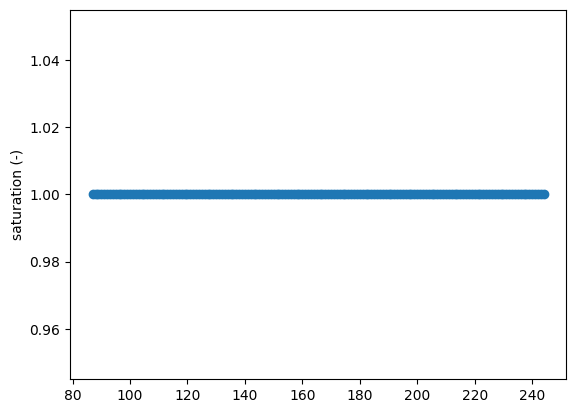

In [100]:
df1[(df1['X']==4.25)&(df1['Z']==259.79225)]
plt.plot(df1[(df1['X']==4.25)&(df1['Z']==259.76724)&(df1['t']>86)]['t'],df1[(df1['X']==4.25)&(df1['Z']==259.76724)&(df1['t']>86)]['sat'],'o-')
plt.ylabel('saturation (-)')

Text(0, 0.5, 'saturation (-)')

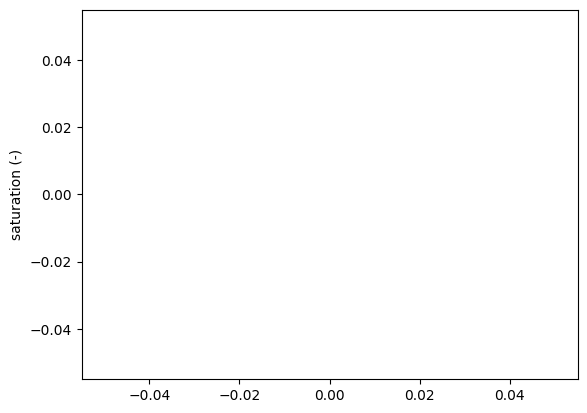

In [139]:
plt.plot(df1[(df1['X']==8.25)&(df1['Z']==260.86482)&(df1['t']>86)]['t'],df1[(df1['X']==8.25)&(df1['Z']==260.86482)&(df1['t']>86)]['sat'],'o-')
plt.ylabel('saturation (-)')

In [101]:
df1.to_csv(folder+'/data_set_edit.txt',index=False)

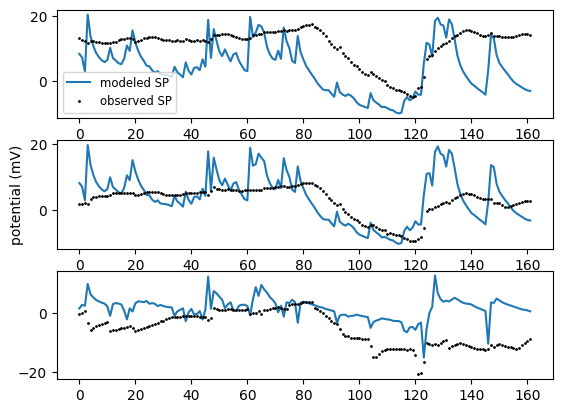

In [62]:
res=pd.read_csv(folder+'/result_norm.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
fig,ax=plt.subplots(3,1)
ax[0].plot((res.iloc[2280,85:]-res.iloc[505,85:]).values*1000, label='modeled SP')

ax[1].plot((res.iloc[2249,85:]-res.iloc[505,85:]).values*1000)

ax[2].plot((res.iloc[520,85:]-res.iloc[505,85:]).values*1000)

SP_a=pd.read_csv('data/SP_a_2.txt').iloc[:162,:].values.reshape(-1,)
SP_b=pd.read_csv('data/SP_b_2.txt').iloc[:162,:].values.reshape(-1,)
SP_c=pd.read_csv('data/SP_c_2.txt').iloc[:162,:].values.reshape(-1,)
ax[0].plot(SP_a,'ko',markersize=1, label='observed SP')
ax[1].plot(SP_b,'ko',markersize=1); ax[2].plot(SP_c,'ko',markersize=1)
ax[1].set_ylabel('potential (mV)')
ax[0].legend(fontsize='small')

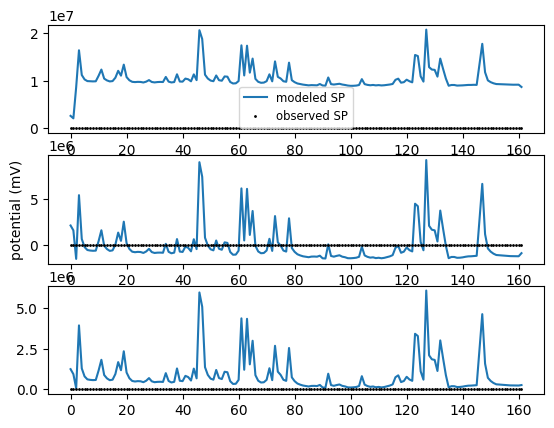

In [127]:
res=pd.read_csv(folder+'/result_high_k_norm_qv.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
fig,ax=plt.subplots(3,1)
ax[0].plot((res.iloc[2280,85:]-res.iloc[505,85:]).values*1000, label='modeled SP')

ax[1].plot((res.iloc[2249,85:]-res.iloc[505,85:]).values*1000)

ax[2].plot((res.iloc[520,85:]-res.iloc[505,85:]).values*1000)

SP_a=pd.read_csv('data/SP_a_2.txt').iloc[:162,:].values.reshape(-1,)
SP_b=pd.read_csv('data/SP_b_2.txt').iloc[:162,:].values.reshape(-1,)
SP_c=pd.read_csv('data/SP_c_2.txt').iloc[:162,:].values.reshape(-1,)
ax[0].plot(SP_a,'ko',markersize=1, label='observed SP')
ax[1].plot(SP_b,'ko',markersize=1); ax[2].plot(SP_c,'ko',markersize=1)
ax[1].set_ylabel('potential (mV)')
ax[0].legend(fontsize='small')

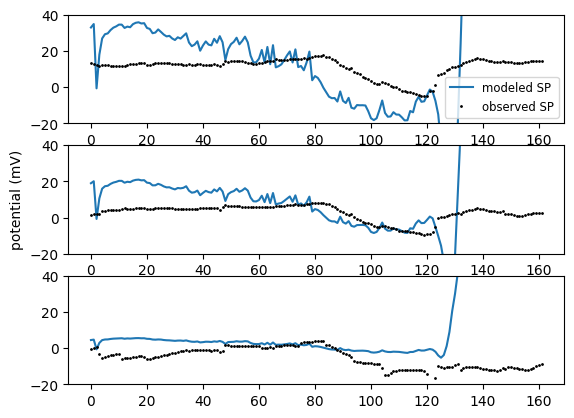

In [84]:
res=pd.read_csv(folder+'/result_low_k_norm_qv.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
fig,ax=plt.subplots(3,1)
ax[0].plot((res.iloc[2280,85:]-res.iloc[505,85:]).values*1000, label='modeled SP')

ax[1].plot((res.iloc[2249,85:]-res.iloc[505,85:]).values*1000)

ax[2].plot((res.iloc[520,85:]-res.iloc[505,85:]).values*1000)

SP_a=pd.read_csv('data/SP_a_2.txt').iloc[:162,:].values.reshape(-1,)
SP_b=pd.read_csv('data/SP_b_2.txt').iloc[:162,:].values.reshape(-1,)
SP_c=pd.read_csv('data/SP_c_2.txt').iloc[:162,:].values.reshape(-1,)
ax[0].plot(SP_a,'ko',markersize=1, label='observed SP')
ax[1].plot(SP_b,'ko',markersize=1); ax[2].plot(SP_c,'ko',markersize=1)
ax[1].set_ylabel('potential (mV)')
ax[0].set_ylim(-20,40); ax[1].set_ylim(-20,40); ax[2].set_ylim(-20,40)
ax[0].legend(fontsize='small')

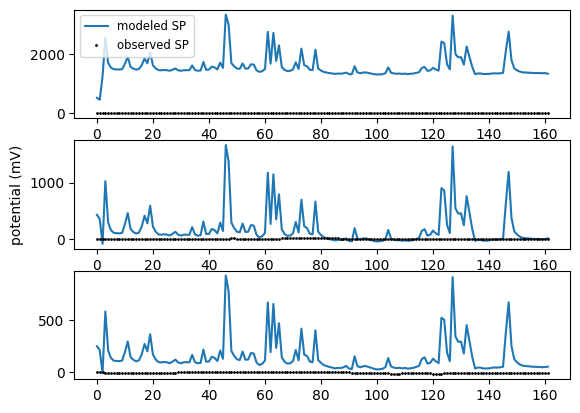

In [178]:
res=pd.read_csv(folder+'/result_high_k_res_qv.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
fig,ax=plt.subplots(3,1)
ax[0].plot((res.iloc[2280,85:]-res.iloc[505,85:]).values*1000, label='modeled SP')

ax[1].plot((res.iloc[2249,85:]-res.iloc[505,85:]).values*1000)

ax[2].plot((res.iloc[520,85:]-res.iloc[505,85:]).values*1000)

SP_a=pd.read_csv('data/SP_a_2.txt').iloc[:162,:].values.reshape(-1,)
SP_b=pd.read_csv('data/SP_b_2.txt').iloc[:162,:].values.reshape(-1,)
SP_c=pd.read_csv('data/SP_c_2.txt').iloc[:162,:].values.reshape(-1,)
ax[0].plot(SP_a,'ko',markersize=1, label='observed SP')
ax[1].plot(SP_b,'ko',markersize=1); ax[2].plot(SP_c,'ko',markersize=1)
ax[1].set_ylabel('potential (mV)')
ax[0].legend(fontsize='small')

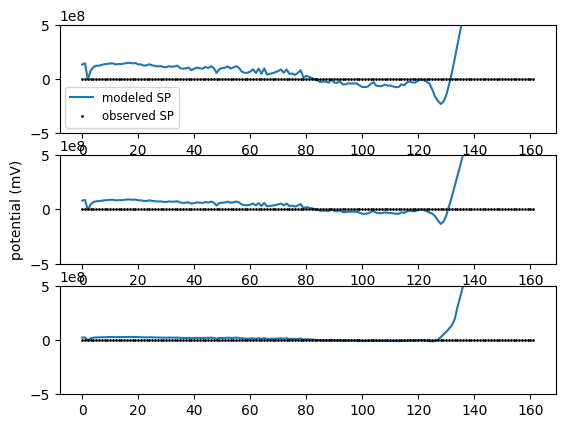

In [103]:
res=pd.read_csv(folder+'/result_low_k_res_qv.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
fig,ax=plt.subplots(3,1)
ax[0].plot((res.iloc[2280,85:]-res.iloc[505,85:]).values*1000, label='modeled SP')

ax[1].plot((res.iloc[2249,85:]-res.iloc[505,85:]).values*1000)

ax[2].plot((res.iloc[520,85:]-res.iloc[505,85:]).values*1000)

SP_a=pd.read_csv('data/SP_a_2.txt').iloc[:162,:].values.reshape(-1,)
SP_b=pd.read_csv('data/SP_b_2.txt').iloc[:162,:].values.reshape(-1,)
SP_c=pd.read_csv('data/SP_c_2.txt').iloc[:162,:].values.reshape(-1,)
ax[0].plot(SP_a,'ko',markersize=1, label='observed SP')
ax[1].plot(SP_b,'ko',markersize=1); ax[2].plot(SP_c,'ko',markersize=1)
ax[1].set_ylabel('potential (mV)')
#ax[0].set_ylim(-20,40); ax[1].set_ylim(-20,40); ax[2].set_ylim(-20,40)
ax[0].set_ylim(-0.5e9,0.5e9); ax[1].set_ylim(-0.5e9,0.5e9); ax[2].set_ylim(-0.5e9,0.5e9)
ax[0].legend(fontsize='small')

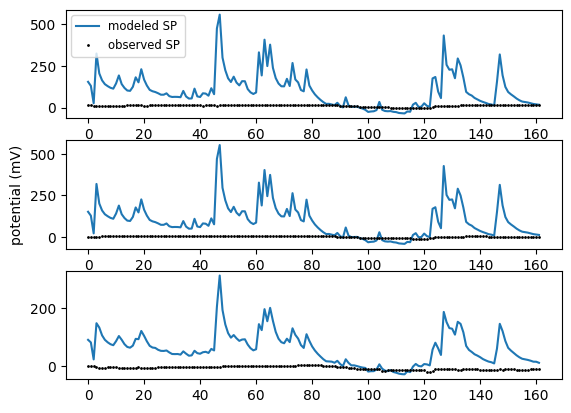

In [183]:
folder='Final_Step1'
res=pd.read_csv(folder+'/result_slight_high_k.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
fig,ax=plt.subplots(3,1)
ax[0].plot((res.iloc[2280,85:]-res.iloc[505,85:]).values*1000, label='modeled SP')

ax[1].plot((res.iloc[2249,85:]-res.iloc[505,85:]).values*1000)

ax[2].plot((res.iloc[520,85:]-res.iloc[505,85:]).values*1000)

SP_a=pd.read_csv('data/SP_a_2.txt').iloc[:162,:].values.reshape(-1,)
SP_b=pd.read_csv('data/SP_b_2.txt').iloc[:162,:].values.reshape(-1,)
SP_c=pd.read_csv('data/SP_c_2.txt').iloc[:162,:].values.reshape(-1,)
ax[0].plot(SP_a,'ko',markersize=1, label='observed SP')
ax[1].plot(SP_b,'ko',markersize=1); ax[2].plot(SP_c,'ko',markersize=1)
ax[1].set_ylabel('potential (mV)')
ax[0].legend(fontsize='small')

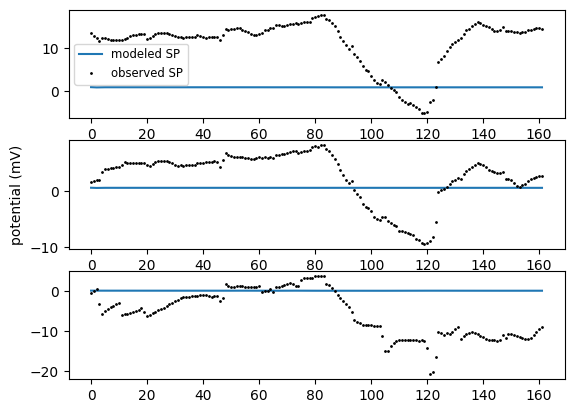

In [184]:
folder='Final_Step1_temp'
res=pd.read_csv(folder+'/result_slight_low_k.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
fig,ax=plt.subplots(3,1)
ax[0].plot((res.iloc[2280,85:]-res.iloc[505,85:]).values*1000, label='modeled SP')

ax[1].plot((res.iloc[2249,85:]-res.iloc[505,85:]).values*1000)

ax[2].plot((res.iloc[520,85:]-res.iloc[505,85:]).values*1000)

SP_a=pd.read_csv('data/SP_a_2.txt').iloc[:162,:].values.reshape(-1,)
SP_b=pd.read_csv('data/SP_b_2.txt').iloc[:162,:].values.reshape(-1,)
SP_c=pd.read_csv('data/SP_c_2.txt').iloc[:162,:].values.reshape(-1,)
ax[0].plot(SP_a,'ko',markersize=1, label='observed SP')
ax[1].plot(SP_b,'ko',markersize=1); ax[2].plot(SP_c,'ko',markersize=1)
ax[1].set_ylabel('potential (mV)')
ax[0].legend(fontsize='small')

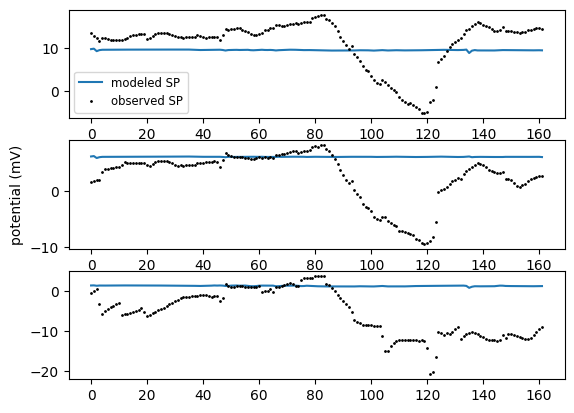

In [201]:
folder='Final_Step1_temp'
res=pd.read_csv(folder+'/result.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
fig,ax=plt.subplots(3,1)
ax[0].plot((res.iloc[2280,85:]-res.iloc[505,85:]).values*1000, label='modeled SP')

ax[1].plot((res.iloc[2249,85:]-res.iloc[505,85:]).values*1000)

ax[2].plot((res.iloc[520,85:]-res.iloc[505,85:]).values*1000)

SP_a=pd.read_csv('data/SP_a_2.txt').iloc[:162,:].values.reshape(-1,)
SP_b=pd.read_csv('data/SP_b_2.txt').iloc[:162,:].values.reshape(-1,)
SP_c=pd.read_csv('data/SP_c_2.txt').iloc[:162,:].values.reshape(-1,)
ax[0].plot(SP_a,'ko',markersize=1, label='observed SP')
ax[1].plot(SP_b,'ko',markersize=1); ax[2].plot(SP_c,'ko',markersize=1)
ax[1].set_ylabel('potential (mV)')
ax[0].legend(fontsize='small')

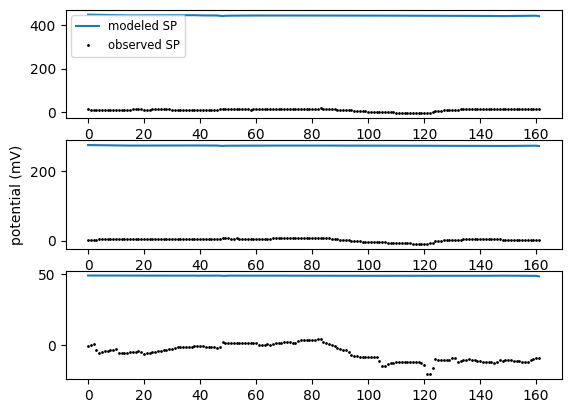

In [107]:
res=pd.read_csv(folder+'/result.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
fig,ax=plt.subplots(3,1)
ax[0].plot((res.iloc[2280,85:]-res.iloc[505,85:]).values*1000, label='modeled SP')

ax[1].plot((res.iloc[2249,85:]-res.iloc[505,85:]).values*1000)

ax[2].plot((res.iloc[520,85:]-res.iloc[505,85:]).values*1000)

SP_a=pd.read_csv('data/SP_a_2.txt').iloc[:162,:].values.reshape(-1,)
SP_b=pd.read_csv('data/SP_b_2.txt').iloc[:162,:].values.reshape(-1,)
SP_c=pd.read_csv('data/SP_c_2.txt').iloc[:162,:].values.reshape(-1,)
ax[0].plot(SP_a,'ko',markersize=1, label='observed SP')
ax[1].plot(SP_b,'ko',markersize=1); ax[2].plot(SP_c,'ko',markersize=1)
ax[1].set_ylabel('potential (mV)')
ax[0].legend(fontsize='small')

Text(0, 0.5, 'modeled potential (mV)')

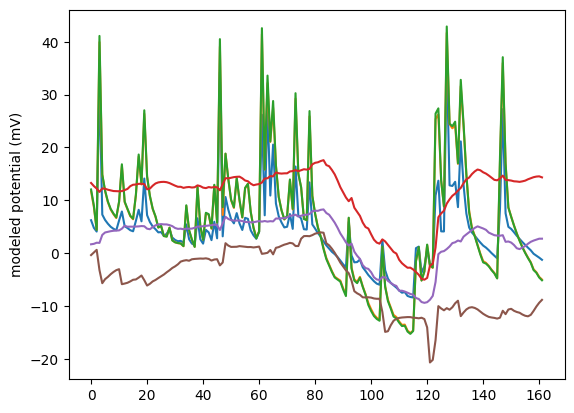

In [35]:
res=pd.read_csv('1yr_run/result.txt',skiprows=8,delimiter ='\s+').iloc[:,:247]
plt.plot((res.iloc[105,85:]-res.iloc[138,85:]).values*1000)

plt.plot((res.iloc[167,85:]-res.iloc[138,85:]).values*1000)

plt.plot((res.iloc[3559,85:]-res.iloc[138,85:]).values*1000)

#SP_a=pd.read_csv('data/SP_a_2.txt').iloc[:162,:].values.reshape(-1,)
#SP_b=pd.read_csv('data/SP_b_2.txt').iloc[:162,:].values.reshape(-1,)
#SP_c=pd.read_csv('data/SP_c_2.txt').iloc[:162,:].values.reshape(-1,)
plt.plot(SP_a); plt.plot(SP_b); plt.plot(SP_c)
plt.ylabel('modeled potential (mV)')

In [102]:
4.95e-14*.75#/1.5

3.7125e-14

In [103]:
2.26e-14*.75

1.695e-14